In [33]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.model_selection import cross_val_score

# For showing all the the Data Frame columns
%matplotlib inline
pd.set_option('display.max_columns', None) 

In [34]:
from utils import *

In [35]:
df_s = pd.read_csv('../data/reduced_data.csv')

In [36]:
df_s = df_s.drop(['timestamp', 'LPS', 'Pressure_switch', 'Oil_level', 
                  'Caudal_impulses', 'minute', 'hour', 'MPG', 'COMP'], axis=1).reset_index(drop=True)

In [37]:
df_s.isna().sum()

TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
DV_eletric         0
Towers             0
failure            0
month              0
day                0
dtype: int64

In [38]:
# Select target and features
X = df_s.drop('failure', axis=1)
y = df_s['failure'].astype(int)

In [39]:
y.dtype

dtype('int64')

In [40]:
# Split the data in a way that the test data contains 1 of the failures and the train 3 of the failures
split_index = int(len(df_s) * 0.7)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [41]:
print(y_test.unique())

[0 1]


In [44]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import recall_score, f1_score
import numpy as np

# Suppress optuna logs except warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    
    # 1 — Hyperparameters to tune
    params = {
        'rf__n_estimators':    trial.suggest_categorical('n_estimators', [100, 200, 300, 500]),
        'rf__max_depth':       trial.suggest_categorical('max_depth', [10, 20, 30, None]),
        'rf__min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'rf__min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 4),
        'rf__max_features':    trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'smote__sampling_strategy': trial.suggest_categorical('sampling_strategy', [0.05, 0.1, 0.25, 0.5])
    }
    
    # 2 — Pipeline: SMOTE → Random Forest
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    # 3 — Set parameters
    pipeline.set_params(**params)
    
    # 4 — Train
    pipeline.fit(X_train, y_train)
    
    # 5 — Predict (no threshold, no predict_proba!)
    y_pred = pipeline.predict(X_test)
    
    # 6 — Metrics ONLY for class 1
    recall_class1 = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_class1     = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    
    # 7 — Combined score to optimize (equal weight)
    combined_score = (recall_class1 + f1_class1) / 2
    
    return combined_score

# Run optimization
study = optuna.create_study(direction='maximize')  # maximize recall + f1 class 1
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Best results
print("="*50)
print(f"Best combined score: {study.best_value:.4f}")
print(f"Best parameters:     {study.best_params}")
print("="*50)

# Train final model with best parameters
best_params = study.best_params

best_pipeline = ImbPipeline([
    ('smote', SMOTE(
        sampling_strategy=best_params['sampling_strategy'],
        random_state=42
    )),
    ('rf', RandomForestClassifier(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)

print("\nFinal Model Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0: 100%|██████████| 30/30 [11:32<00:00, 23.08s/it]


Best combined score: 0.0000
Best parameters:     {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'log2', 'sampling_strategy': 0.1}

Final Model Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     75546
           1       0.00      0.00      0.00       270

    accuracy                           1.00     75816
   macro avg       0.50      0.50      0.50     75816
weighted avg       0.99      1.00      0.99     75816



In [51]:

y_probs = best_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= 0.15).astype(int)


Final Model Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     75546
           1       0.00      0.00      0.00       270

    accuracy                           1.00     75816
   macro avg       0.50      0.50      0.50     75816
weighted avg       0.99      1.00      0.99     75816



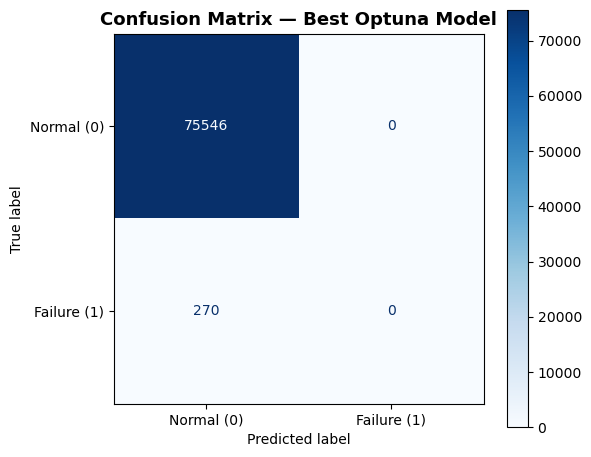


Class 1 Key Metrics:
Recall    class 1: 0.0000
F1        class 1: 0.0000
Best combined score: 0.0000
Best parameters:     {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'log2', 'sampling_strategy': 0.1}


In [52]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Classification Report
print("\nFinal Model Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Normal (0)', 'Failure (1)'])
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — Best Optuna Model', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Extra — key metrics for class 1 only
print("\nClass 1 Key Metrics:")
print(f"Recall    class 1: {recall_score(y_test, y_pred_best, pos_label=1, zero_division=0):.4f}")
print(f"F1        class 1: {f1_score(y_test, y_pred_best, pos_label=1, zero_division=0):.4f}")
print(f"Best combined score: {study.best_value:.4f}")
print(f"Best parameters:     {study.best_params}")